## Precipitation Function

In [9]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

In [21]:
df = pd.read_csv("data/wind_and_precipitation_data.csv")
df['DATE'] = pd.to_datetime(df['DATE'])

df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')

df = df[df['DATE'] >= pd.to_datetime("2000-01-01")]
df['PRCP'] = df['PRCP'].astype(float)

# Drop rows with outliers
df.drop(df[df["PRCP"] == 99.99].index, inplace=True)
df['PRCP'] = df['PRCP'] * 0.0254 # Convert inches to meters

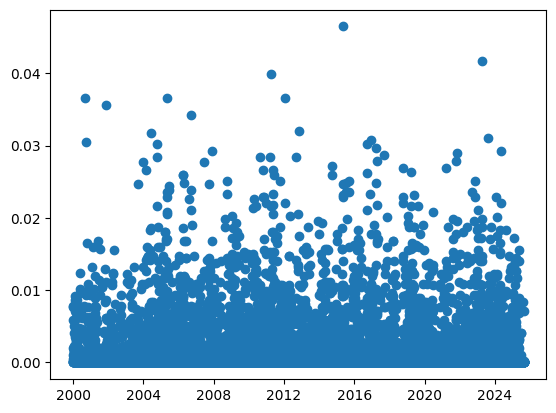

In [22]:
plt.scatter(df["DATE"], df["PRCP"])
plt.show()

In [23]:
df = df.groupby('DATE')["PRCP"].mean()

In [140]:
# # Fill in missing dates
# idx = pd.date_range('2000-01-01', '2025-08-27')
# df.index = pd.DatetimeIndex(df.index)
# df = df.reindex(idx, fill_value=0)

In [24]:
prcp_vals = df.values

In [25]:
# Creating interpolated function
y = prcp_vals
x = np.arange(len(y))

def sinusoid(t, A, B, phi, C):
    return A * np.sin(B * t + phi) + C

A0 = (y.max() - y.min()) / 2
B0 = 2 * np.pi / 365.25
phi0 = 0
C0 = y.mean()

params, _ = curve_fit(sinusoid, x, y, p0=[A0, B0, phi0, C0])
A_fit, B_fit, phi_fit, C_fit = params

df["fit"] = sinusoid(x, A_fit, B_fit, phi_fit, C_fit)

In [27]:
print(params)
len(prcp_vals)

[3.62510665e-04 1.72209593e-02 5.55109972e-01 1.07152734e-03]


9371

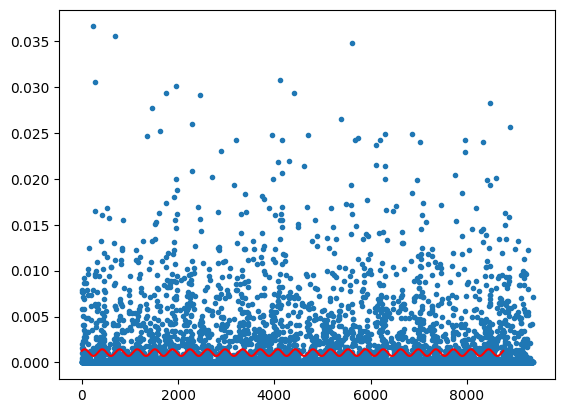

In [30]:
plt.scatter(np.arange(9371), prcp_vals, marker='.')
plt.plot(np.arange(365*24), list(df["fit"][:365])*24, color='red')

plt.show()

# Functions

In [150]:
prcp_vals

array([0.      , 0.007874, 0.002032, ..., 0.      , 0.      , 0.007112])

In [159]:
idx = pd.date_range('2000-01-01', '2025-08-27')
historical_precipitation_values = pd.DataFrame()
historical_precipitation_values.index = pd.DatetimeIndex(idx)
historical_precipitation_values["Precip"] = prcp_vals
historical_precipitation_values.to_csv("data/historical_precipitation_values.csv")

In [160]:
def precipitation(V, t):
    A, B, phi, C = 3.62510665e-04, 1.72209593e-02, 5.55109972e-01, 1.07152734e-03
    return (V**2/3) * (A * np.sin(B * t + phi) + C)

In [164]:
1.07152734e-03

0.00107152734

In [148]:
# plt.plot(np.arange(365), precipitation(500, np.arange(365)))
# plt.show()